In [1]:
import pandas as pd

data = [

[1,"Ali Khan","Web Development","Very good website design and fast delivery",5,"Positive"],
[2,"Sara Ahmed","AI Solutions","Excellent AI solution and great support",5,"Positive"],
[3,"Usman Malik","Data Science","Data analysis was accurate and helpful",4,"Positive"],
[4,"Ayesha Noor","Cloud Computing","Cloud service performance is amazing",5,"Positive"],
[5,"Hamza Ali","Mobile App","App works smoothly and looks professional",4,"Positive"],

[6,"Fatima Khan","Web Development","Website is okay but needs small improvements",3,"Neutral"],
[7,"Bilal Ahmed","AI Solutions","The service was acceptable",3,"Neutral"],
[8,"Zain Malik","Data Science","Average experience with the project",3,"Neutral"],
[9,"Mariam Noor","Cloud Computing","Service quality was normal",3,"Neutral"],
[10,"Ahmed Raza","Mobile App","App is fine but could be better",3,"Neutral"],

[11,"Hira Khan","Web Development","Project delivery was delayed and poor",2,"Negative"],
[12,"Saad Ali","AI Solutions","Support was not good",2,"Negative"],
[13,"Amna Tariq","Data Science","The results were disappointing",1,"Negative"],
[14,"Farhan Malik","Cloud Computing","Service had many problems",2,"Negative"],
[15,"Iqra Noor","Mobile App","Application had several errors",1,"Negative"],

[16,"Talha Khan","Web Development","Amazing experience and quality work",5,"Positive"],
[17,"Sana Ahmed","AI Solutions","Highly satisfied with the solution",5,"Positive"],
[18,"Adnan Ali","Data Science","Good analysis and professional team",4,"Positive"],
[19,"Areeba Khan","Cloud Computing","Reliable and fast service",5,"Positive"],
[20,"Shayan Malik","Mobile App","Very useful application",4,"Positive"],

[21,"Noor Fatima","Web Development","The work was average",3,"Neutral"],
[22,"Danish Ahmed","AI Solutions","Nothing special but acceptable",3,"Neutral"],
[23,"Laiba Khan","Data Science","Project completed normally",3,"Neutral"],
[24,"Hassan Ali","Cloud Computing","Service was satisfactory",3,"Neutral"],
[25,"Mehwish Noor","Mobile App","Experience was okay",3,"Neutral"],

[26,"Jawad Khan","Web Development","Very bad communication",1,"Negative"],
[27,"Kiran Ahmed","AI Solutions","Project quality was poor",2,"Negative"],
[28,"Umer Malik","Data Science","Not satisfied with results",1,"Negative"],
[29,"Nida Fatima","Cloud Computing","Many issues occurred",2,"Negative"],
[30,"Rehan Ali","Mobile App","App performance was terrible",1,"Negative"]

]


columns=[
"Feedback_ID",
"Client_Name",
"Service",
"Feedback_Text",
"Rating",
"Sentiment"
]


df=pd.DataFrame(data,columns=columns)


df.to_csv(
"coretech_feedback.csv",
index=False
)

print("CSV Created")

CSV Created


In [2]:
import pandas as pd

df=pd.read_csv("coretech_feedback.csv")

df.head()

,Feedback_ID,Client_Name,Service,Feedback_Text,Rating,Sentiment
0,1,Ali Khan,Web Development,Very good website design and fast delivery,5,Positive
1,2,Sara Ahmed,AI Solutions,Excellent AI solution and great support,5,Positive
2,3,Usman Malik,Data Science,Data analysis was accurate and helpful,4,Positive
3,4,Ayesha Noor,Cloud Computing,Cloud service performance is amazing,5,Positive
4,5,Hamza Ali,Mobile App,App works smoothly and looks professional,4,Positive


In [3]:
import re


def clean_text(text):

    text=text.lower()

    text=re.sub(
        r"[^a-z\s]",
        "",
        text
    )

    return text


df["clean_feedback"]=df["Feedback_Text"].apply(clean_text)


df.head()

,Feedback_ID,Client_Name,Service,Feedback_Text,Rating,Sentiment,clean_feedback
0,1,Ali Khan,Web Development,Very good website design and fast delivery,5,Positive,very good website design and fast delivery
1,2,Sara Ahmed,AI Solutions,Excellent AI solution and great support,5,Positive,excellent ai solution and great support
2,3,Usman Malik,Data Science,Data analysis was accurate and helpful,4,Positive,data analysis was accurate and helpful
3,4,Ayesha Noor,Cloud Computing,Cloud service performance is amazing,5,Positive,cloud service performance is amazing
4,5,Hamza Ali,Mobile App,App works smoothly and looks professional,4,Positive,app works smoothly and looks professional


In [4]:
sentiment_count=df["Sentiment"].value_counts()

print(sentiment_count)

Sentiment
Positive    10
Neutral     10
Negative    10
Name: count, dtype: int64


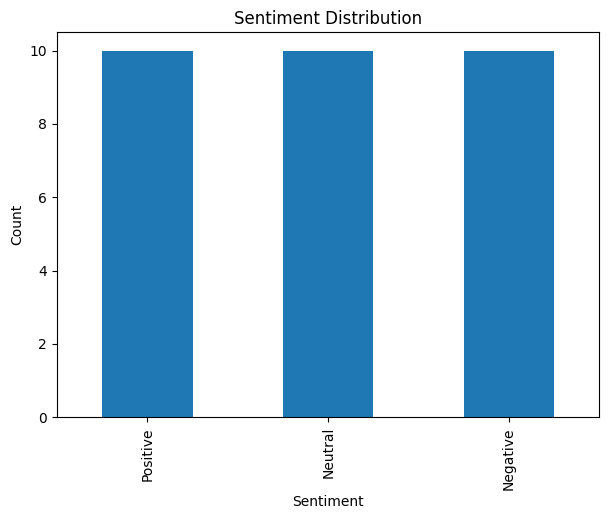

In [5]:
import matplotlib.pyplot as plt


sentiment_count.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")


plt.savefig(
"sentiment_chart.png"
)


plt.show()

In [6]:
from collections import Counter


words = " ".join(
df["clean_feedback"]
).split()


common_words = Counter(words)


print(
common_words.most_common(10)
)

[('was', 10), ('and', 8), ('service', 6), ('the', 5), ('project', 4), ('very', 3), ('good', 3), ('is', 3), ('app', 3), ('but', 3)]


In [7]:
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
accuracy_score,
classification_report
)

In [8]:
X=df["clean_feedback"]

y=df["Sentiment"]


X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [9]:
vectorizer=CountVectorizer()


X_train_vector=vectorizer.fit_transform(
X_train
)


X_test_vector=vectorizer.transform(
X_test
)

In [10]:
model=MultinomialNB()


model.fit(
X_train_vector,
y_train
)


print(
"Model Trained"
)

Model Trained


In [11]:
predictions=model.predict(
X_test_vector
)

print(predictions)

['Negative' 'Positive' 'Negative' 'Positive' 'Negative' 'Neutral']


In [12]:
accuracy=accuracy_score(
y_test,
predictions
)


print(
"Accuracy:",
accuracy
)

Accuracy: 0.6666666666666666


In [13]:
print(
classification_report(
y_test,
predictions
)
)

              precision    recall  f1-score   support

    Negative       0.33      1.00      0.50         1
     Neutral       1.00      0.33      0.50         3
    Positive       1.00      1.00      1.00         2

    accuracy                           0.67         6
   macro avg       0.78      0.78      0.67         6
weighted avg       0.89      0.67      0.67         6



In [14]:
from google.colab import files

files.download("coretech_feedback.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
from google.colab import files

files.download("sentiment_chart.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>